In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

IR_DIR = "/content/drive/MyDrive/INSAT3D/insat3d_ir_cyclone_ds/CYCLONE_DATASET_INFRARED"

files = os.listdir(IR_DIR)

print("Number of files:", len(files))

for f in files[:20]:
    print(f)

Number of files: 136
102.jpg
106.jpg
111.jpg
112.jpg
101.jpg
30(1).jpg
37.jpg
25.jpg
35(2).jpg
34.jpg
39.jpg
41.jpg
128.jpg
33(1).jpg
35(1).jpg
27.jpg
119.jpg
32(1).jpg
35.jpg
32.jpg


In [ ]:
from collections import Counter

extensions = Counter(
    os.path.splitext(f)[1].lower()
    for f in files
)

print(extensions)

Counter({'.jpg': 136})


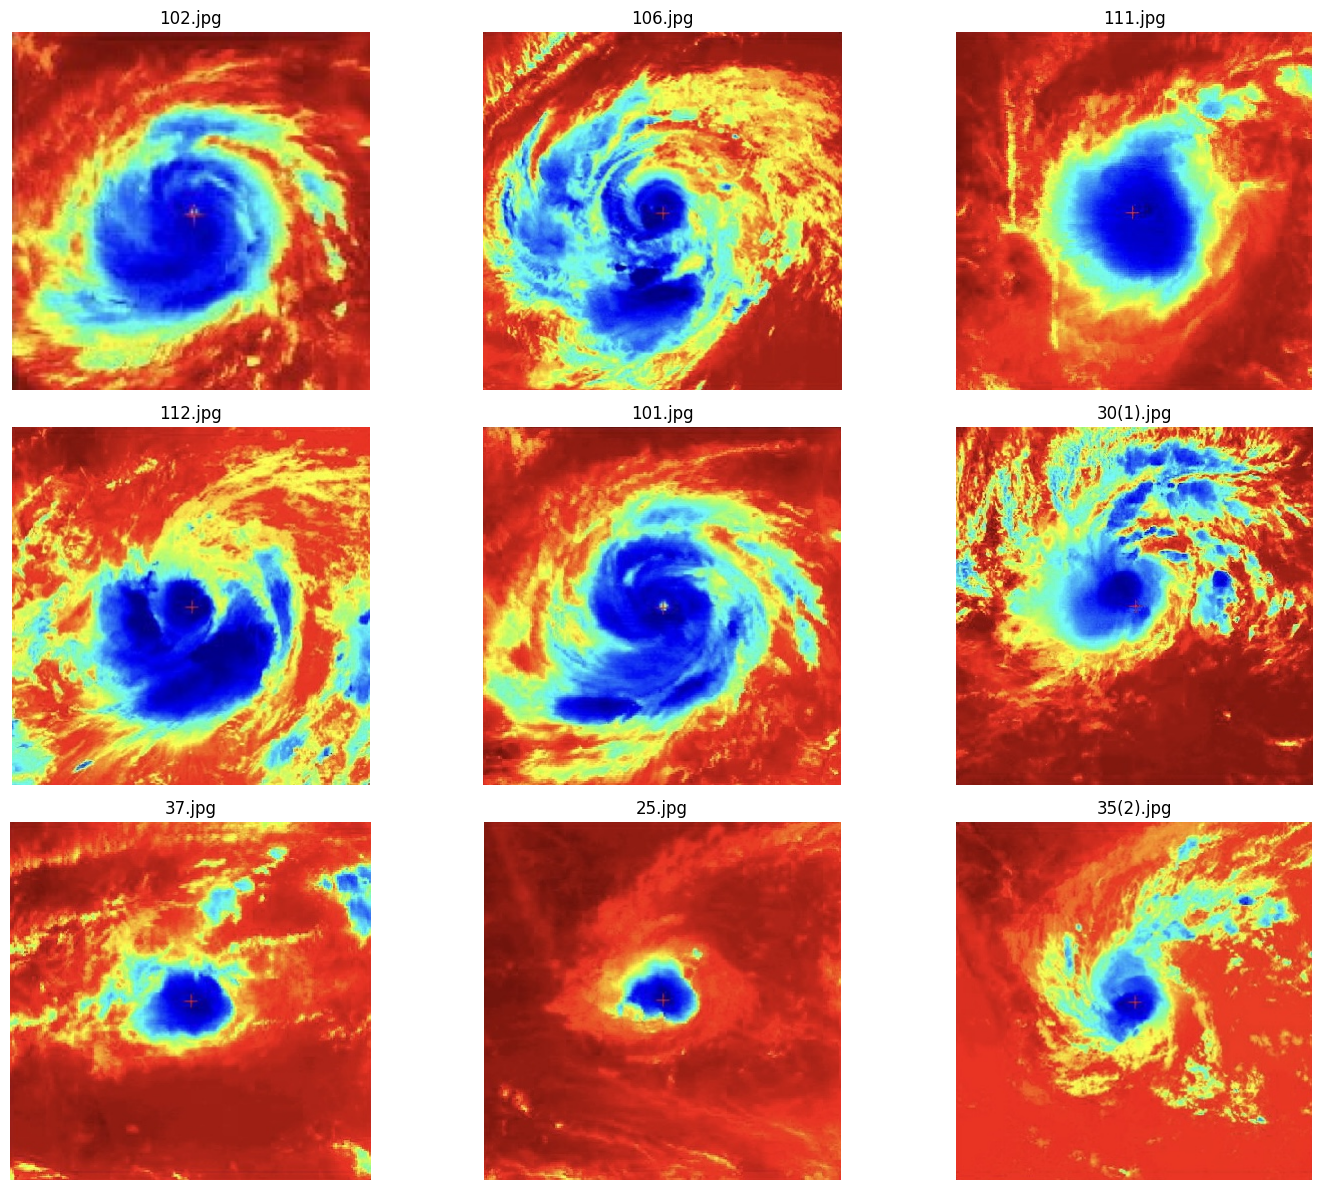

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image

IR_DIR = "/content/drive/MyDrive/INSAT3D/insat3d_ir_cyclone_ds/CYCLONE_DATASET_INFRARED"

files = [
    f for f in os.listdir(IR_DIR)
    if f.lower().endswith(".jpg")
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for ax, filename in zip(axes.ravel(), files[:9]):
    path = os.path.join(IR_DIR, filename)

    img = Image.open(path)

    ax.imshow(img)
    ax.set_title(filename)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
for filename in files[:10]:
    path = os.path.join(IR_DIR, filename)
    img = Image.open(path)

    print(
        filename,
        "| size =", img.size,
        "| mode =", img.mode
    )

102.jpg | size = (166, 166) | mode = RGB
106.jpg | size = (358, 357) | mode = RGB
111.jpg | size = (356, 358) | mode = RGB
112.jpg | size = (357, 357) | mode = RGB
101.jpg | size = (357, 357) | mode = RGB
30(1).jpg | size = (357, 358) | mode = RGB
37.jpg | size = (360, 357) | mode = RGB
25.jpg | size = (356, 357) | mode = RGB
35(2).jpg | size = (357, 359) | mode = RGB
34.jpg | size = (360, 358) | mode = RGB


In [ ]:
import re

def numeric_part(filename):
    return int(re.search(r'\d+', filename).group())

sorted_files = sorted(files, key=numeric_part)

print("First 50:")
print(sorted_files[:50])

print("\nLast 20:")
print(sorted_files[-20:])

First 50:
['25.jpg', '27.jpg', '28.jpg', '30(1).jpg', '30.jpg', '31.jpg', '32(1).jpg', '32.jpg', '33(1).jpg', '33(2).jpg', '33.jpg', '34.jpg', '34(1).jpg', '35(2).jpg', '35(1).jpg', '35.jpg', '35(3).jpg', '36.jpg', '36(1).jpg', '36(3).jpg', '36(2).jpg', '37.jpg', '38.jpg', '39.jpg', '40(3).jpg', '40(1).jpg', '40.jpg', '40(2).jpg', '41.jpg', '42.jpg', '42(3).jpg', '43(2).jpg', '43.jpg', '44.jpg', '44(2).jpg', '44(3).jpg', '44(1).jpg', '45(1).jpg', '45(4).jpg', '45(2).jpg', '45.jpg', '45(3).jpg', '46(3).jpg', '46(1).jpg', '46.jpg', '47(3).jpg', '47(2).jpg', '47(1).jpg', '47(4).jpg', '47.jpg']

Last 20:
['84.jpg', '85(1).jpg', '85(2).jpg', '85.jpg', '86(1).jpg', '86.jpg', '86(2).jpg', '87.jpg', '94.jpg', '98.jpg', '99.jpg', '101.jpg', '102.jpg', '106.jpg', '111.jpg', '112.jpg', '115.jpg', '118.jpg', '119.jpg', '128.jpg']


In [ ]:
import os
import pandas as pd

IR_DIR = "/content/drive/MyDrive/INSAT3D/insat3d_ir_cyclone_ds/CYCLONE_DATASET_INFRARED"
CSV_PATH = "/content/drive/MyDrive/INSAT3D/insat_3d_ds - Sheet.csv"

df = pd.read_csv(CSV_PATH)

# Build complete image paths
df["image_path"] = df["img_name"].apply(
    lambda x: os.path.join(IR_DIR, x)
)

# Check whether every image exists
df["exists"] = df["image_path"].apply(os.path.exists)

print("Total rows:", len(df))
print("Images found:", df["exists"].sum())
print("Images missing:", (~df["exists"]).sum())

display(df.head())

Total rows: 136
Images found: 136
Images missing: 0


,img_name,label,image_path,exists
0,25.jpg,25,/content/drive/MyDrive/INSAT3D/insat3d_ir_cycl...,True
1,27.jpg,27,/content/drive/MyDrive/INSAT3D/insat3d_ir_cycl...,True
2,28.jpg,28,/content/drive/MyDrive/INSAT3D/insat3d_ir_cycl...,True
3,30.jpg,30,/content/drive/MyDrive/INSAT3D/insat3d_ir_cycl...,True
4,30(1).jpg,30,/content/drive/MyDrive/INSAT3D/insat3d_ir_cycl...,True


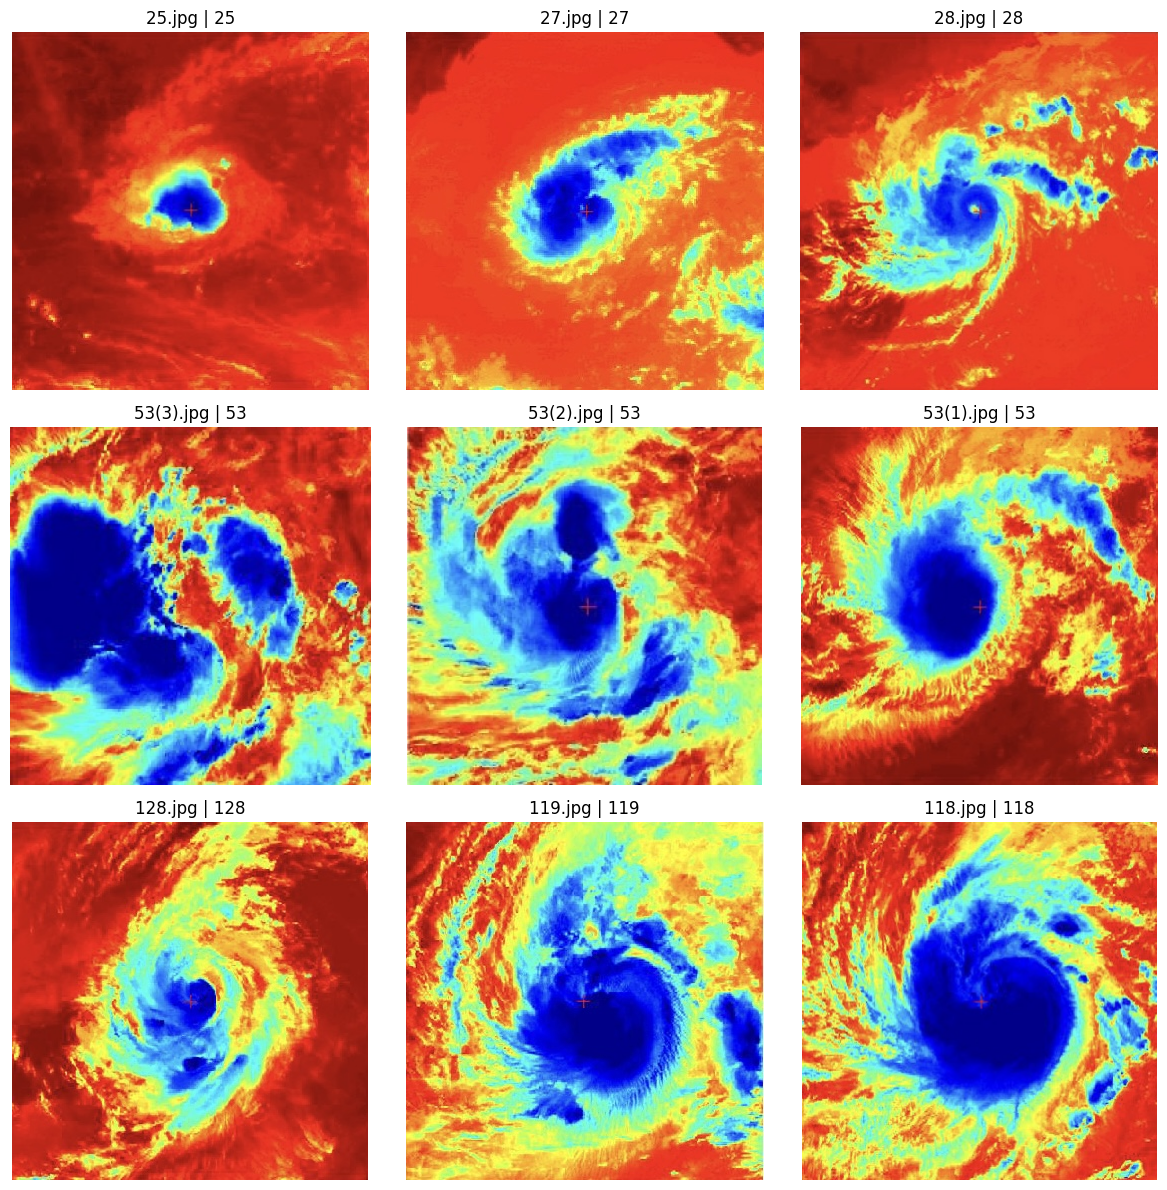

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

# Pick images from low, medium and high intensity
low = df.nsmallest(3, "label")
mid = df.iloc[(df["label"] - df["label"].median()).abs().argsort()[:3]]
high = df.nlargest(3, "label")

sample_df = pd.concat([low, mid, high])

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for ax, (_, row) in zip(axes.ravel(), sample_df.iterrows()):
    img = Image.open(row["image_path"])

    ax.imshow(img)
    ax.set_title(f'{row["img_name"]} | {row["label"]}')
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 108
Validation: 14
Test: 14


In [ ]:
class_mapping = {
    "Low": 0,
    "Moderate": 1,
    "Severe": 2,
    "Very Severe": 3,
    "Extreme": 4
}

df["class_id"] = df["intensity_class"].map(class_mapping)

print(df[["img_name", "label", "intensity_class", "class_id"]].head(15))

     img_name  label intensity_class class_id
0      25.jpg     25             Low        0
1      27.jpg     27             Low        0
2      28.jpg     28             Low        0
3      30.jpg     30             Low        0
4   30(1).jpg     30             Low        0
5      31.jpg     31             Low        0
6      32.jpg     32             Low        0
7   32(1).jpg     32             Low        0
8      33.jpg     33             Low        0
9   33(1).jpg     33             Low        0
10  33(2).jpg     33             Low        0
11     34.jpg     34        Moderate        1
12  34(1).jpg     34        Moderate        1
13     35.jpg     35        Moderate        1
14  35(1).jpg     35        Moderate        1


In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["class_id"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["class_id"]
)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

print("\nTrain distribution:")
print(train_df["class_id"].value_counts().sort_index())

print("\nValidation distribution:")
print(val_df["class_id"].value_counts().sort_index())

print("\nTest distribution:")
print(test_df["class_id"].value_counts().sort_index())

Train: 108
Val: 14
Test: 14

Train distribution:
class_id
0     9
1    31
2    33
3    18
4    17
Name: count, dtype: int64

Validation distribution:
class_id
0    1
1    4
2    4
3    2
4    3
Name: count, dtype: int64

Test distribution:
class_id
0    1
1    4
2    4
3    3
4    2
Name: count, dtype: int64


In [ ]:
import torch
import torch.nn as nn
class CycloneClassificationDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = Image.open(
            row["image_path"]
        ).convert("RGB")

        label = torch.tensor(
            row["class_id"],
            dtype=torch.long
        )

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
from torchvision import transforms

train_transform_v4 = transforms.Compose([
    transforms.Resize((256, 256)),

    transforms.RandomResizedCrop(
        224,
        scale=(0.88, 1.0)
    ),

    transforms.RandomRotation(
        degrees=10
    ),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform_v4 = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
test_transform_cls = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
train_dataset_v4 = CycloneClassificationDataset(
    train_df,
    train_transform_v4
)

val_dataset_v4 = CycloneClassificationDataset(
    val_df,
    test_transform_v4
)

test_dataset_v4 = CycloneClassificationDataset(
    test_df,
    test_transform_v4
)



In [ ]:
from torch.utils.data import WeightedRandomSampler

class_counts = (
    train_df["class_id"]
    .value_counts()
    .sort_index()
)

class_weights = 1.0 / class_counts

sample_weights = train_df["class_id"].map(
    class_weights
).values

sample_weights = torch.DoubleTensor(
    sample_weights
)

sampler_v4 = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(train_df),
    replacement=True
)

In [ ]:
train_loader_v4 = DataLoader(
    train_dataset_v4,
    batch_size=16,
    sampler=sampler_v4
)

val_loader_v4 = DataLoader(
    val_dataset_v4,
    batch_size=16,
    shuffle=False
)

test_loader_v4 = DataLoader(
    test_dataset_v4,
    batch_size=16,
    shuffle=False
)

In [ ]:
import torch
import torch.nn as nn

from torchvision.models import (
    resnet18,
    ResNet18_Weights
)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model_v4 = resnet18(
    weights=ResNet18_Weights.DEFAULT
)

In [ ]:
for param in model_v4.parameters():
    param.requires_grad = False
for param in model_v4.layer4.parameters():
    param.requires_grad = True
num_features = model_v4.fc.in_features

model_v4.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(num_features, 5)
)

model_v4 = model_v4.to(device)

In [ ]:
criterion_v4 = nn.CrossEntropyLoss()


In [ ]:
optimizer_v4 = torch.optim.AdamW(
    [
        {
            "params": model_v4.layer4.parameters(),
            "lr": 1e-5
        },
        {
            "params": model_v4.fc.parameters(),
            "lr": 1e-4
        }
    ],
    weight_decay=1e-4
)

In [ ]:
def train_v4(model, loader, criterion, optimizer):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()
        optimizer.step()

        total_loss += (
            loss.item() * images.size(0)
        )

        predictions = outputs.argmax(dim=1)

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    return (
        total_loss / total,
        correct / total
    )


def validate_v4(model, loader, criterion):

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            total_loss += (
                loss.item() * images.size(0)
            )

            predictions = outputs.argmax(dim=1)

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    return (
        total_loss / total,
        correct / total
    )

In [ ]:
best_val_loss = float("inf")
best_state = None

patience = 10
patience_counter = 0

EPOCHS = 50

for epoch in range(EPOCHS):

    train_loss, train_acc = train_v4(
        model_v4,
        train_loader_v4,
        criterion_v4,
        optimizer_v4
    )

    val_loss, val_acc = validate_v4(
        model_v4,
        val_loader_v4,
        criterion_v4
    )

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.3f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.3f}"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model_v4.state_dict().items()
        }

        patience_counter = 0

        print("  ✓ Best model saved")

    else:

        patience_counter += 1

        if patience_counter >= patience:

            print("Early stopping.")
            break

Epoch 01/50 | Train Loss: 1.9743 | Train Acc: 0.139 | Val Loss: 1.7476 | Val Acc: 0.143
  ✓ Best model saved
Epoch 02/50 | Train Loss: 1.8091 | Train Acc: 0.167 | Val Loss: 1.5643 | Val Acc: 0.286
  ✓ Best model saved
Epoch 03/50 | Train Loss: 1.8473 | Train Acc: 0.148 | Val Loss: 1.4833 | Val Acc: 0.500
  ✓ Best model saved
Epoch 04/50 | Train Loss: 1.6838 | Train Acc: 0.231 | Val Loss: 1.4415 | Val Acc: 0.500
  ✓ Best model saved
Epoch 05/50 | Train Loss: 1.6360 | Train Acc: 0.278 | Val Loss: 1.4007 | Val Acc: 0.571
  ✓ Best model saved
Epoch 06/50 | Train Loss: 1.6063 | Train Acc: 0.287 | Val Loss: 1.3816 | Val Acc: 0.500
  ✓ Best model saved
Epoch 07/50 | Train Loss: 1.5524 | Train Acc: 0.324 | Val Loss: 1.3746 | Val Acc: 0.500
  ✓ Best model saved
Epoch 08/50 | Train Loss: 1.5763 | Train Acc: 0.287 | Val Loss: 1.3757 | Val Acc: 0.571
Epoch 09/50 | Train Loss: 1.4297 | Train Acc: 0.435 | Val Loss: 1.3737 | Val Acc: 0.571
  ✓ Best model saved
Epoch 10/50 | Train Loss: 1.4561 | Train

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

model_v4.eval()

all_labels = []
all_preds = []

with torch.no_grad():

    for images, labels in test_loader_v4:

        images = images.to(device)

        outputs = model_v4(images)

        predictions = outputs.argmax(
            dim=1
        ).cpu().numpy()

        all_preds.extend(predictions)
        all_labels.extend(labels.numpy())

accuracy = accuracy_score(
    all_labels,
    all_preds
)

balanced_acc = balanced_accuracy_score(
    all_labels,
    all_preds
)

macro_f1 = f1_score(
    all_labels,
    all_preds,
    average="macro",
    zero_division=0
)

print(f"Accuracy:          {accuracy:.3f}")
print(f"Balanced Accuracy: {balanced_acc:.3f}")
print(f"Macro F1:          {macro_f1:.3f}")

Accuracy:          0.214
Balanced Accuracy: 0.200
Macro F1:          0.202


In [ ]:
class_names = [
    "Low",
    "Moderate",
    "Severe",
    "Very Severe",
    "Extreme"
]

print(
    classification_report(
        all_labels,
        all_preds,
        labels=[0,1,2,3,4],
        target_names=class_names,
        zero_division=0
    )
)

              precision    recall  f1-score   support

         Low       0.00      0.00      0.00         1
    Moderate       0.33      0.25      0.29         4
      Severe       0.20      0.25      0.22         4
 Very Severe       0.00      0.00      0.00         3
     Extreme       0.50      0.50      0.50         2

    accuracy                           0.21        14
   macro avg       0.21      0.20      0.20        14
weighted avg       0.22      0.21      0.22        14

